In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sys
from sklearn import datasets
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay,f1_score

C:\Users\PGCP-AI\AppData\Local\anaconda3\envs\dnn\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
inpDir = Path('../input')
outDir = Path('../output')

RANDOM_STATE = 24 # REMEMBER: to remove at the time of promotion to production
np.random.RandomState(seed=RANDOM_STATE) # Set Random Seed for reproducible  results
tf.random.set_seed(RANDOM_STATE)

EPOCHS = 100 # number of epochs
ALPHA = 0.001 # learning rate
TEST_SIZE = 0.2

In [3]:
#are there GPUs available?
physical_devices=tf.config.list_physical_devices('GPU')
#if there are, set memory growth to True
if len(physical_devices)>0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

In [4]:
data_df=pd.read_csv('wine.csv',header=None)
data_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [5]:

data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       178 non-null    float64
 1   1       178 non-null    float64
 2   2       178 non-null    float64
 3   3       178 non-null    float64
 4   4       178 non-null    int64  
 5   5       178 non-null    float64
 6   6       178 non-null    float64
 7   7       178 non-null    float64
 8   8       178 non-null    float64
 9   9       178 non-null    float64
 10  10      178 non-null    float64
 11  11      178 non-null    float64
 12  12      178 non-null    int64  
 13  13      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
1,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
2,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
3,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
4,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
5,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
6,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
7,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
8,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
9,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


<Axes: >

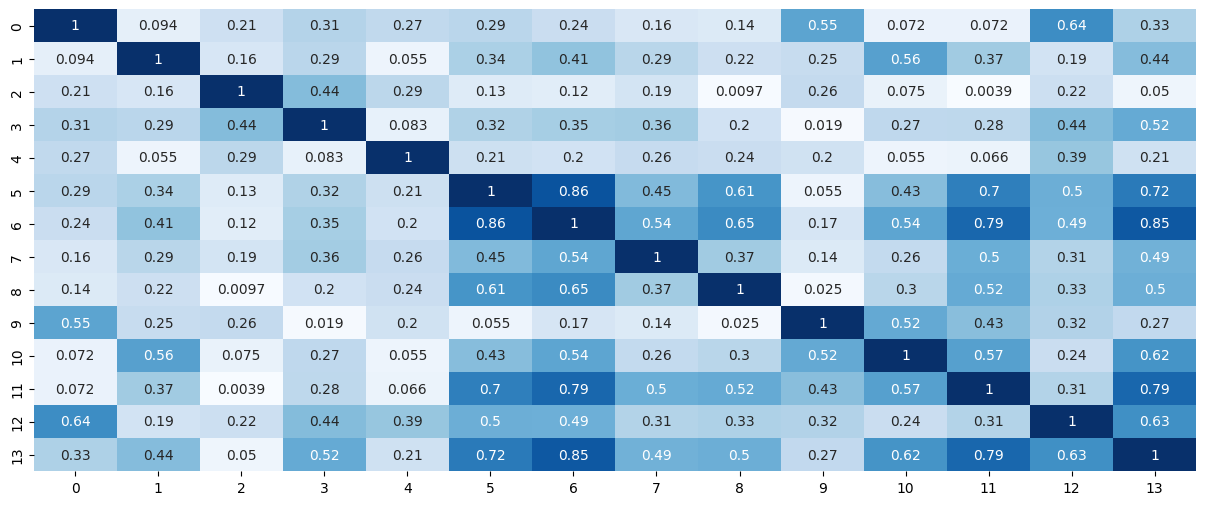

In [7]:
gfig,ax=plt.subplots(figsize=(15,6))
sns.heatmap(data_df.corr().abs(),annot=True,fmt='.2g',cmap='Blues',ax=ax,cbar=False)

In [8]:
for col in data_df.columns:
    print(f'{col}:{data_df[col].nunique()}')

0:126
1:133
2:79
3:63
4:53
5:97
6:132
7:39
8:101
9:132
10:78
11:122
12:121
13:3


In [9]:
labels=data_df[data_df.columns[-1]]
features=data_df.drop(columns=data_df.columns[-1])
features.shape,labels.shape

((178, 13), (178,))

In [10]:
X_train, X_test, y_train, y_test=train_test_split(features,labels,test_size=TEST_SIZE,random_state=RANDOM_STATE,stratify=labels)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((142, 13), (36, 13), (142,), (36,))

In [11]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [12]:
le=LabelEncoder()
y_train=le.fit_transform(y_train)
y_test=le.transform(y_test)

In [13]:
X_train.shape[1],len(le.classes_)

(13, 3)

In [14]:
sys.float_info.max

1.7976931348623157e+308

In [15]:
model=tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(len(le.classes_)),
])

Functional API, Extend model class

In [16]:
X_train[:1].shape

(1, 13)

In [17]:
prediction=model(X_train[:1]).numpy()

In [18]:
prediction.sum()

np.float32(-5.052942)

In [19]:
tf.nn.softmax(prediction).numpy().sum()

np.float32(0.99999994)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │             112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 139 (556.00 B)

 Trainable params: 139 (556.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer=tf.keras.optimizers.Adam(learning_rate=ALPHA)

In [23]:
model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy'],
)

In [24]:
history=model.fit(X_train,y_train,epochs=EPOCHS,validation_data=[X_test,y_test])

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.2183 - loss: 1.4816 - val_accuracy: 0.1389 - val_loss: 1.5512
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2324 - loss: 1.4360 - val_accuracy: 0.1944 - val_loss: 1.5048
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2535 - loss: 1.3930 - val_accuracy: 0.1944 - val_loss: 1.4594
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2817 - loss: 1.3516 - val_accuracy: 0.1944 - val_loss: 1.4155
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3099 - loss: 1.3116 - val_accuracy: 0.1944 - val_loss: 1.3727
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3451 - loss: 1.2726 - val_accuracy: 0.1944 - val_loss: 1.3318
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3803 - loss: 1.2347 - val_accuracy: 0.1944 - val_loss: 1.2916
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3873 - loss: 1.1979 - val_accuracy: 0.2222 - val_loss:

In [25]:
loss_df=pd.DataFrame(history.history)
loss_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.218310,1.481636,0.138889,1.551160
1,0.232394,1.436032,0.194444,1.504850
2,0.253521,1.392989,0.194444,1.459390
3,0.281690,1.351635,0.194444,1.415522
4,0.309859,1.311554,0.194444,1.372745


<Axes: >

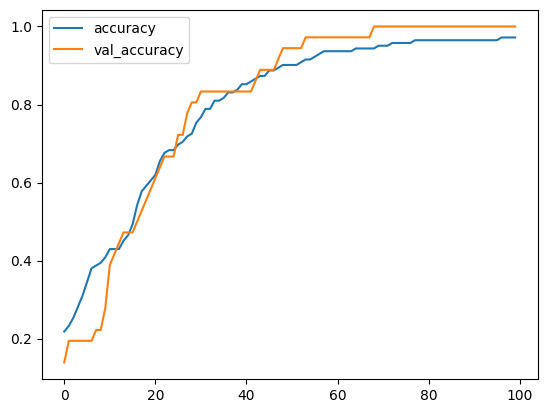

In [26]:
loss_df[['accuracy','val_accuracy']].plot()

In [27]:
y_pred = model.predict(X_test)
accuracy_score = accuracy_score(y_test, y_pred.argmax(axis=1))
print(accuracy_score)
loss_df.iloc[-1][loss_df.columns[1]]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1.0


np.float64(0.11692710965871811)

In [28]:
def fn_plot_tf_hist(hist_df):
    fig,axes=plt.subplots(1,2,figsize=(15,6))
    props=dict(boxstyle='round',facecolor='aqua',alpha=0.4)
    facecolor='cyan'
    fontsize=12
    cmap=plt.cm.coolwarm
    best=hist_df[hist_df['val_loss']==hist_df['val_loss'].min()]
    ax=axes[0]
    loss_df[['loss','val_loss']].plot(ax=ax,colormap=cmap)
    txtFmt='Loss:\n     train:{:6.4f}\n      test:{:6.4f}'
    txtstr=txtFmt.format(hist_df.iloc[-1]['loss'],
                         hist_df.iloc[-1]['val_loss'])
    ax.text(0.3,0.95,txtstr,transform=ax.transAxes,fontsize=fontsize,
           verticalalignment='top',bbox=props)

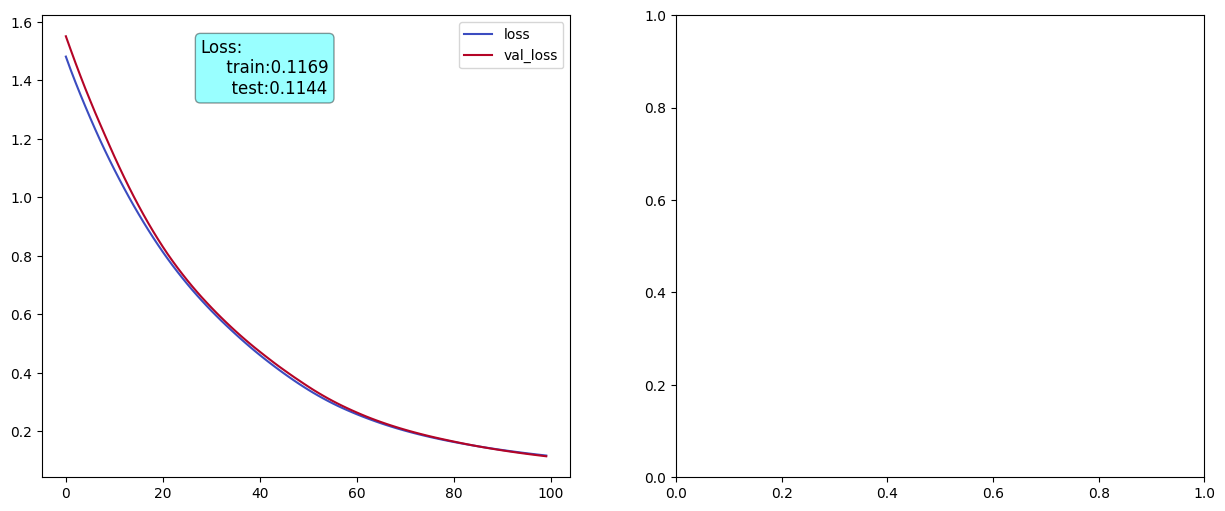

In [29]:
fn_plot_tf_hist(loss_df)

<Axes: >

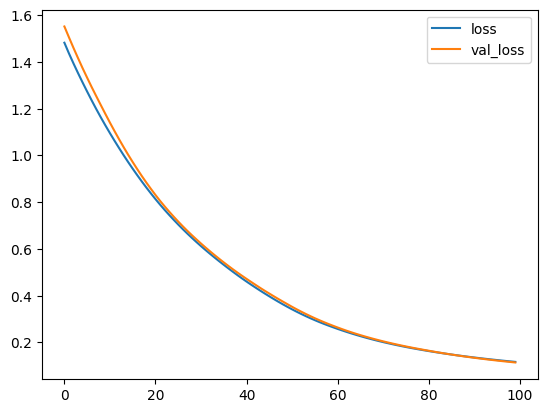

In [30]:
loss_df[['loss','val_loss']].plot()

In [31]:
def fn_plot_tf_hist(hist_df):
    
    '''
    Args:
        hist_df: a DataFrame with column names accuracy,loss	val_accuracy	val_loss
    '''
        
    fig, axes = plt.subplots(1,2 , figsize = (15,6))

    # properties  matplotlib.patch.Patch 
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)
    facecolor = 'cyan'
    fontsize=12
    CMAP = plt.cm.coolwarm
    
    # Get columns by index to eliminate any column naming error
    y1 = hist_df.columns[0]
    y2 = hist_df.columns[1]
    y3 = hist_df.columns[2]
    y4 = hist_df.columns[3]

    # Where was min loss
    best = hist_df[hist_df[y4] == hist_df[y4].min()]
    
    ax = axes[0]

    hist_df.plot(y = [y2,y4], ax = ax, colormap=CMAP)


    # little beautification
    txtFmt = "Loss: \n  train: {:6.4f}\n   test: {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y2],
                           hist_df.iloc[-1][y4]) #text to plot
    
    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)
    
    # calculate offset for arrow
    y_min = min(hist_df[y2].min(), hist_df[y4].min())
    y_max = max(hist_df[y2].max(), hist_df[y4].max())
    offset = (y_max-y_min)/10.0
    
    best_idx = best.index.to_numpy()[0]  # Extract first (and only) element as scalar
    best_value = best[y4].to_numpy()[0]   # Extract scalar value
    
    # Mark arrow at lowest
    ax.annotate(f'Min: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value + offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y2.capitalize())
    ax.set_title('Loss Curve')
    ax.grid(True)
    ax.legend(loc = 'upper left') # model legend to upper left
    
    ax = axes[1]

    hist_df.plot( y = [y1, y3], ax = ax, colormap=CMAP)
    
    # little beautification
    txtFmt = "Accuracy: \n  train: {:6.4f}\n  test:  {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y1],
                           hist_df.iloc[-1][y3]) #text to plot

    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.2, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # calculate offset for arroe
    y_min = min(hist_df[y1].min(), hist_df[y3].min())
    y_max = max(hist_df[y1].max(), hist_df[y3].max())
    offset = (y_max-y_min)/10.0

    best_value = best[y3].to_numpy()[0]   # Extract scalar value
    # Mark arrow at lowest
    ax.annotate(f'Best: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value-offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y1.capitalize())
    ax.set_title('Accuracy Curve')
    ax.grid(True)
    ax.legend(loc = 'lower left')
    
    plt.tight_layout()

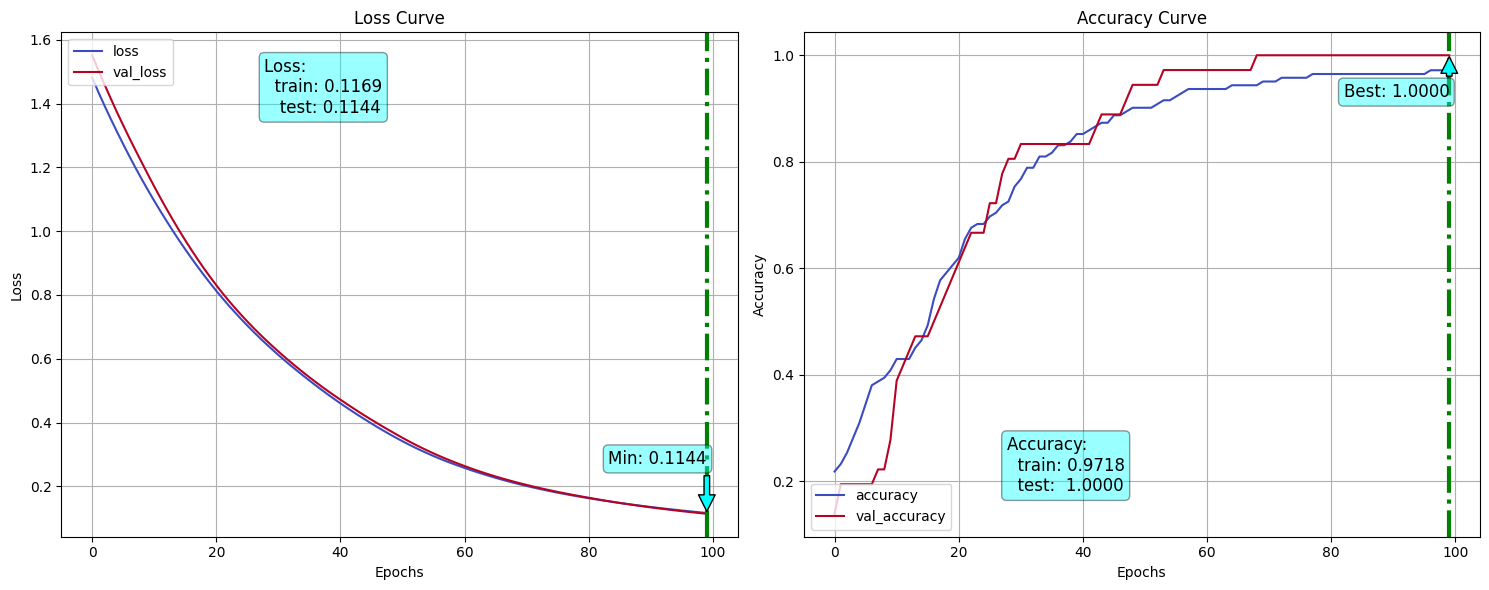

In [32]:
fn_plot_tf_hist(loss_df)

In [33]:
loss_df[loss_df['val_loss'] == loss_df['val_loss'].min()]

,accuracy,loss,val_accuracy,val_loss
99,0.971831,0.116927,1.0,0.114418


In [34]:
probability_model = tf.keras.Sequential([
  model,
  tf.keras.layers.Softmax()
])

In [35]:
y_pred = probability_model(X_train).numpy()
y_pred.shape

(142, 3)

In [36]:
accuracy_score(y_train, y_pred.argmax(axis=1))

TypeError: 'float' object is not callable

In [37]:
print(classification_report( y_train, y_pred.argmax( axis = 1)))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        47
           1       0.98      0.95      0.96        57
           2       0.97      1.00      0.99        38

    accuracy                           0.97       142
   macro avg       0.97      0.98      0.97       142
weighted avg       0.97      0.97      0.97       142



In [38]:
y_pred = probability_model(X_test).numpy()
print('Accuracy score on Test Data :{:.5f}'.format(accuracy_score(y_test, np.argmax(y_pred, axis = 1))))

TypeError: 'float' object is not callable

In [39]:
print(classification_report(y_test, 
                            np.argmax(y_pred, axis = 1)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [40]:
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : dictonary
    
    '''
    
    cm  = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels.values())
    
    fig, ax = plt.subplots(figsize = (4,4))
    
    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)
    # Disable the grid
    ax.grid(False)
    ax.set_title(f"F1_Score: {f1_score(y_test,y_pred, average='weighted'):0.4f}")
    plt.show()

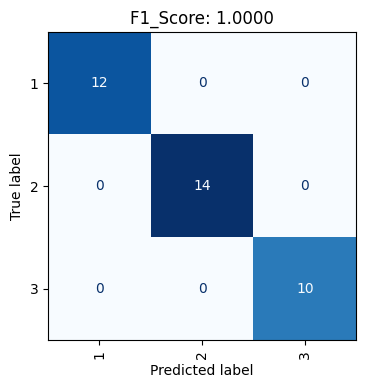

In [41]:
class_labels = {0: 1, 1:2, 2:3}
fn_plot_confusion_matrix( y_test, y_pred.argmax( axis = 1), labels=class_labels)